C:\Users\herra\AppData\Local\Temp\ipykernel_109112\1053276589.py:127: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(pad=2.0)


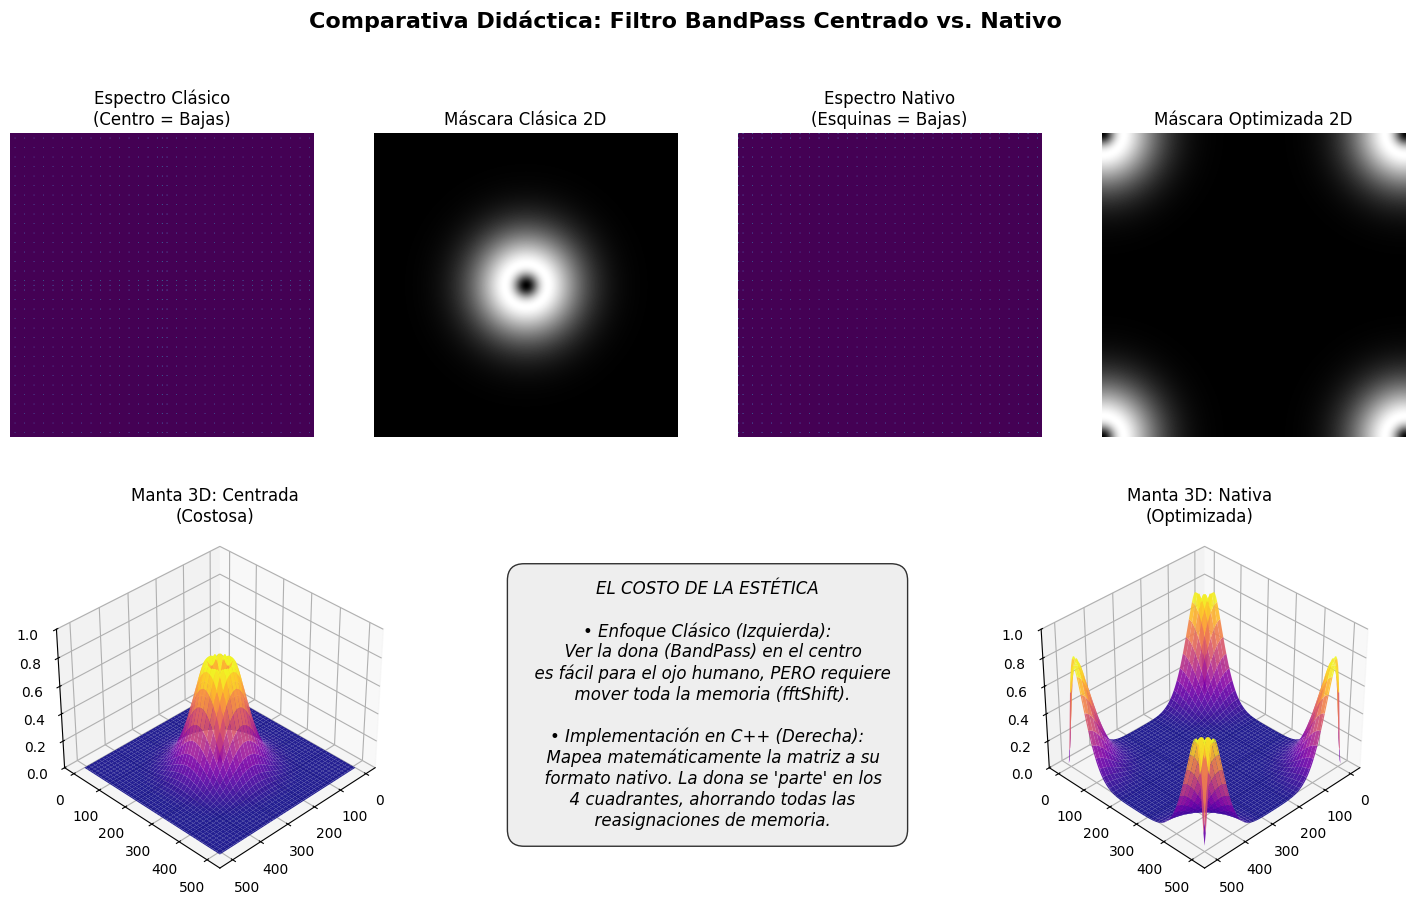

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def generar_mascara_nativa(shape, tipo, p1, p2=0.0):
    """
    Recrea exactamente el switch-case de tu motor C++.
    Genera la máscara en formato NATIVO (esquinas) sin usar fftShift.
    """
    rows, cols = shape
    mask = np.zeros((rows, cols), dtype=np.float32)
    
    for y in range(rows):
        v = y if y <= rows // 2 else (rows - y)
        for x in range(cols):
            u = x if x <= cols // 2 else (cols - x)
            dist = np.sqrt(u**2 + v**2)
            
            if tipo == 'IdealLow':
                mask[y, x] = 1.0 if dist <= p1 else 0.0
            elif tipo == 'IdealHigh':
                mask[y, x] = 0.0 if dist <= p1 else 1.0
            elif tipo == 'GaussLow':
                mask[y, x] = np.exp(-(dist**2) / (2.0 * (p1**2)))
            elif tipo == 'GaussHigh':
                mask[y, x] = 1.0 - np.exp(-(dist**2) / (2.0 * (p1**2)))
            elif tipo == 'BandPass':
                gHigh = np.exp(-(dist**2) / (2.0 * (p2**2)))
                gLow = np.exp(-(dist**2) / (2.0 * (p1**2)))
                mask[y, x] = gHigh - gLow
            elif tipo == 'BandReject':
                gHigh = np.exp(-(dist**2) / (2.0 * (p2**2)))
                gLow = np.exp(-(dist**2) / (2.0 * (p1**2)))
                mask[y, x] = 1.0 - (gHigh - gLow)
                
    return mask

# 1. Generar imagen sintética limpia (Tablero de ajedrez)
size = 512
imagen_original = np.zeros((size, size), dtype=np.uint8)
for i in range(0, size, 64):
    imagen_original[:, i:i+32] = 255
    imagen_original[i:i+32, :] = 255

# 2. Calcular la FFT 2D (Formato natural/unshifted)
espectro_complejo = np.fft.fft2(imagen_original)
magnitud_log_nativa = np.log(1 + np.abs(espectro_complejo))

# 3. Elegir el tipo de filtro y generarlo
TIPO_FILTRO = 'BandPass'
P1 = 15.0
P2 = 60.0

mascara_nativa = generar_mascara_nativa(imagen_original.shape, TIPO_FILTRO, P1, P2)

# Versión CENTRADA artificialmente
mascara_centrada = np.fft.fftshift(mascara_nativa)
magnitud_log_centrada = np.fft.fftshift(magnitud_log_nativa)

# =====================================================================
# CONFIGURACIÓN DE LA GRAFICACIÓN (GRILLA MIXTA 4x Arriba, 3x Abajo)
# =====================================================================
fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Comparativa Didáctica: Filtro {TIPO_FILTRO} Centrado vs. Nativo', fontsize=16, fontweight='bold')

step = 4 
X, Y = np.meshgrid(np.arange(0, size, step), np.arange(0, size, step))
Z_masc_centrada = mascara_centrada[::step, ::step]
Z_masc_nativa = mascara_nativa[::step, ::step]

# --- FILA SUPERIOR: 4 COLUMNAS (Grilla 2x4) ---
# Usamos los índices 1, 2, 3 y 4 de una grilla de 2 filas y 4 columnas
ax1 = fig.add_subplot(2, 4, 1)
ax1.imshow(magnitud_log_centrada, cmap='viridis')
ax1.set_title('Espectro Clásico\n(Centro = Bajas)')
ax1.axis('off')

ax2 = fig.add_subplot(2, 4, 2)
ax2.imshow(mascara_centrada, cmap='gray')
ax2.set_title('Máscara Clásica 2D')
ax2.axis('off')

ax3 = fig.add_subplot(2, 4, 3)
ax3.imshow(magnitud_log_nativa, cmap='viridis')
ax3.set_title('Espectro Nativo\n(Esquinas = Bajas)')
ax3.axis('off')

ax4 = fig.add_subplot(2, 4, 4)
ax4.imshow(mascara_nativa, cmap='gray')
ax4.set_title('Máscara Optimizada 2D')
ax4.axis('off')

# --- FILA INFERIOR: 3 COLUMNAS (Grilla 2x3) ---
# Usamos los índices 4, 5 y 6 de una grilla imaginaria de 2 filas y 3 columnas
ax5 = fig.add_subplot(2, 3, 4, projection='3d')
ax5.plot_surface(X, Y, Z_masc_centrada, cmap='plasma', edgecolor='none', alpha=0.9)
ax5.set_title('Manta 3D: Centrada\n(Costosa)')
ax5.set_zlim(0, 1)
ax5.view_init(elev=35, azim=45)

ax6 = fig.add_subplot(2, 3, 5) # Panel central de texto
ax6.axis('off')
texto = (
    "EL COSTO DE LA ESTÉTICA\n\n"
    "• Enfoque Clásico (Izquierda):\n"
    "  Ver la dona (BandPass) en el centro\n"
    "  es fácil para el ojo humano, PERO requiere\n"
    "  mover toda la memoria (fftShift).\n\n"
    "• Implementación en C++ (Derecha):\n"
    "  Mapea matemáticamente la matriz a su\n"
    "  formato nativo. La dona se 'parte' en los\n"
    "  4 cuadrantes, ahorrando todas las\n"
    "  reasignaciones de memoria."
)
# Centrado perfecto usando ha='center' y va='center'
ax6.text(0.5, 0.5, texto, fontsize=12, style='italic',
         ha='center', va='center',
         bbox=dict(facecolor='#eaeaea', alpha=0.8, boxstyle='round,pad=1'))

ax7 = fig.add_subplot(2, 3, 6, projection='3d')
ax7.plot_surface(X, Y, Z_masc_nativa, cmap='plasma', edgecolor='none', alpha=0.9)
ax7.set_title('Manta 3D: Nativa\n(Optimizada)')
ax7.set_zlim(0, 1)
ax7.view_init(elev=35, azim=45)

# tight_layout con un poco de padding para que las 3D no se aplasten
plt.tight_layout(pad=2.0)
plt.show()

In [5]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 7.1 MB/s eta 0:00:07
   - -------------------------------------- 2.1/44.0 MB 5.6 MB/s eta 0:00:08
   --- ------------------------------------ 3.7/44.0 MB 6.8 MB/s eta 0:00:06
   ---- ----------------------------------- 5.0/44.0 MB 6.2 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/44.0 MB 6.2 MB/s eta 0:00:07
   ------ --------------------------------- 7.6/44.0 MB 6.2 MB/s eta 0:00:06
   -------- ------------------------------- 8.9/44.0 MB 6.2 MB/s eta 0:00:06
   --------- ------------------------------ 10.7/44.0 MB 6.6 MB/s eta 0:00:06
   ---------- ----------------------------- 12.1/44.0 MB 6.5 MB/s eta 0:00:05
   ------------ --------------------------- 13.4/44.0 MB 6.6 MB/s eta 0:00:05
   ------------- -------------------------- 15.2/44.0 MB 6.6 MB/s eta 0:00:05
 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.65.1 requires numpy<2.5,>=1.22, but you have numpy 2.5.1 which is incompatible.
scipy 1.15.2 requires numpy<2.5,>=1.23.5, but you have numpy 2.5.1 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\herra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


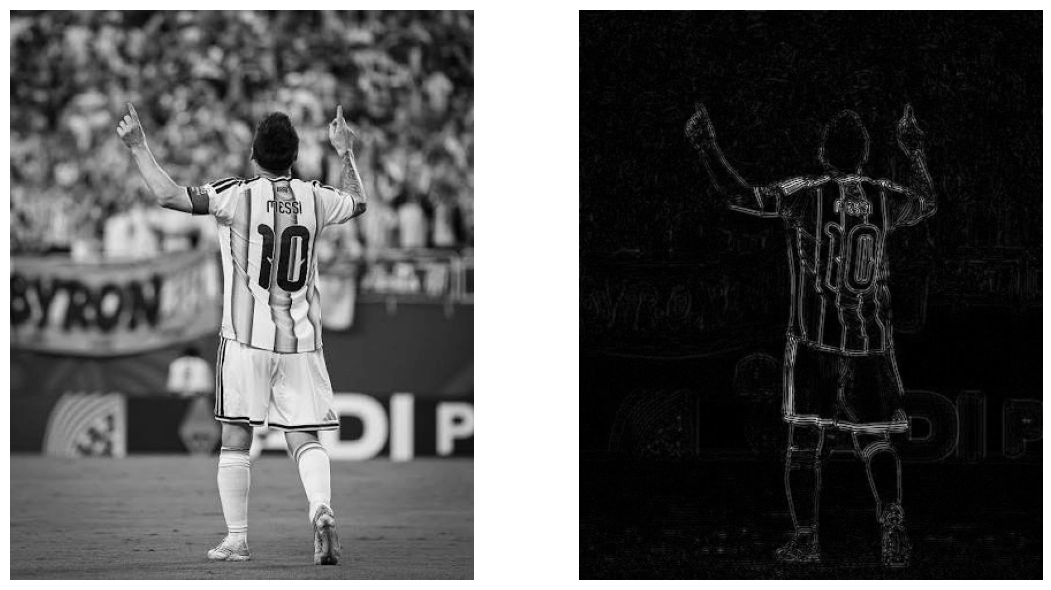

In [7]:
import cv2
import matplotlib.pyplot as plt

def aplicar_laplaciano(ruta_imagen):
    # 1. Cargar la imagen en escala de grises
    # El Laplaciano busca cambios de intensidad, por lo que se trabaja en un solo canal.
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: No se pudo cargar la imagen en '{ruta_imagen}'. Revisa la ruta.")
        return

    # 2. Suavizado Gaussiano (Opcional pero MUY recomendado)
    # El Laplaciano es extremadamente sensible al ruido. Un leve desenfoque ayuda a evitar bordes falsos.
    img_blur = cv2.GaussianBlur(img, (3, 3), 0)

    # 3. Aplicar el filtro Laplaciano
    # Usamos cv2.CV_64F (punto flotante de 64 bits) porque el filtro genera valores negativos 
    # (al pasar de blanco a negro). Si usamos el formato estándar de 8 bits, perderíamos la mitad de los bordes.
    laplacian = cv2.Laplacian(img_blur, cv2.CV_64F)

    # 4. Pasar a valor absoluto y convertir de vuelta a 8 bits (0-255)
    laplacian_8u = cv2.convertScaleAbs(laplacian)

    # 5. Mostrar los resultados con Matplotlib
    plt.figure(figsize=(12, 6))

    # Imagen Original
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    # Imagen Filtrada
    plt.subplot(1, 2, 2)
    plt.imshow(laplacian_8u, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Ejecución del script ---
# Reemplaza con el nombre de tu archivo de imagen
aplicar_laplaciano(r'C:\Users\herra\Desktop\Labo III\TPFINAL_LABO3\Messi.jpg')